<a href="https://colab.research.google.com/github/anusha-1503/Data-Driven-COVID-19-Detection-Trend-Prediction-Using-Machine-Learning/blob/main/ME_228_Report_1_Module_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **COMPLETED PROCESSES**

In [10]:
import pandas as pd
import numpy as np

# 1. Load the Master Dataset
df = pd.read_csv("owid-covid-data.csv")
df['date'] = pd.to_datetime(df['date'])

# 2. Multi-Country Data Alignment
# Selecting primary features and sorting by country (location) and date
cols = ['location', 'date', 'new_cases', 'stringency_index', 'reproduction_rate']
df = df[cols].sort_values(['location', 'date'])

# 3. Handle Missing Values (Forward-Fill)
# Ensuring policy indices (stringency) stay constant during reporting gaps
df = df.groupby('location').apply(lambda x: x.ffill().fillna(0)).reset_index(drop=True)

# 4. Smooth Reporting Noise (7-Day Rolling Average)
# Removes the "weekend effect" mentioned in the report
df['smoothed_cases'] = df.groupby('location')['new_cases'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

print("--- Completed Processing Finished ---")
print(f"Dataset aligned for {df['location'].nunique()} locations.")
df[['location', 'date', 'new_cases', 'smoothed_cases']].head()

/tmp/ipykernel_19790/274383533.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('location').apply(lambda x: x.ffill().fillna(0)).reset_index(drop=True)


--- Completed Processing Finished ---
Dataset aligned for 255 locations.


,location,date,new_cases,smoothed_cases
0,Afghanistan,2020-01-05,0.0,0.0
1,Afghanistan,2020-01-06,0.0,0.0
2,Afghanistan,2020-01-07,0.0,0.0
3,Afghanistan,2020-01-08,0.0,0.0
4,Afghanistan,2020-01-09,0.0,0.0


In [5]:
# --- [Cell 1: Completed Processing] ---

# 1. Load the Master Dataset (Already done)
df = pd.read_csv("owid-covid-data.csv")
df['date'] = pd.to_datetime(df['date'])

# 2. Multi-Country Data Alignment (Already done)
cols = ['location', 'date', 'new_cases', 'stringency_index', 'reproduction_rate']
df = df[cols].sort_values(['location', 'date'])

# 3. Handle Missing Values (PLACE THE NEW LINE HERE)
# This uses the modern pandas syntax to avoid the DeprecationWarning
df = df.groupby('location').apply(lambda x: x.ffill().fillna(0), include_groups=False).reset_index()

# 4. Smooth Reporting Noise (Already done)
# Now that data is filled, we calculate the 7-day average
df['smoothed_cases'] = df.groupby('location')['new_cases'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# 5. Optional: Cleanup the reset_index side-effect
df = df.drop(columns=['level_1'], errors='ignore')

print("--- Completed Processing Finished ---")

--- Completed Processing Finished ---


In [3]:
# Verify your data is actually working
# Look at a specific country during a known wave (e.g., India in 2021)
india_check = df[df['location'] == 'India'].dropna()
print(india_check[india_check['date'] > '2021-04-01'].head(10))

# Or check the maximum values to ensure data exists
print("\nMax cases found in dataset:", df['smoothed_cases'].max())

       location       date  new_cases  stringency_index  reproduction_rate  \
175016    India 2021-04-02        0.0             57.87               1.43   
175017    India 2021-04-03        0.0             74.54               1.45   
175018    India 2021-04-04   513885.0             74.54               1.47   
175019    India 2021-04-05        0.0             69.91               1.48   
175020    India 2021-04-06        0.0             69.91               1.49   
175021    India 2021-04-07        0.0             69.91               1.49   
175022    India 2021-04-08        0.0             69.91               1.49   
175023    India 2021-04-09        0.0             69.91               1.49   
175024    India 2021-04-10        0.0             69.91               1.50   
175025    India 2021-04-11   873296.0             69.91               1.50   

        smoothed_cases  
175016    53213.428571  
175017    53213.428571  
175018    73412.142857  
175019    73412.142857  
175020    73412.

### **INITIAL EXPERIMENTS**

In [6]:
# Feature Engineering

# 1. FEATURE ENGINEERING: LAG FEATURES (t-7, t-14)
# As documented in your report, this provides historical context to the model
# We use the 'smoothed_cases' column we just created in Cell 1
for lag in [7, 14]:
    df[f'lag_cases_{lag}'] = df.groupby('location')['smoothed_cases'].shift(lag)

# 2. EXOGENOUS VARIABLE INTEGRATION
# Normalizing the Stringency Index (0-100) to a 0-1 scale for the neural network
df['norm_stringency'] = df['stringency_index'] / 100.0

# 3. DEFINE TARGET VARIABLE (Multi-Horizon Forecast)
# We want to predict what happens 7 days from "today"
df['target_7d'] = df.groupby('location')['smoothed_cases'].shift(-7)

# 4. DATA CLEANUP
# Dropping rows with NaNs (the first 14 days and last 7 days of each country)
df_final = df.dropna().copy()

print("--- Initial Experiments: Feature Engineering Complete ---")
print(f"Total features ready for Transformer-LSTM: {df_final.columns.tolist()}")
print(f"Total training samples: {len(df_final)}")

# Verification: Look at the relationship between today, the lags, and the target
df_final[['location', 'date', 'smoothed_cases', 'lag_cases_7', 'target_7d']].head(10)


--- Initial Experiments: Feature Engineering Complete ---
Total features ready for Transformer-LSTM: ['location', 'date', 'new_cases', 'stringency_index', 'reproduction_rate', 'smoothed_cases', 'lag_cases_7', 'lag_cases_14', 'norm_stringency', 'target_7d']
Total training samples: 424100


,location,date,smoothed_cases,lag_cases_7,target_7d
14,Afghanistan,2020-01-19,0.0,0.0,0.0
15,Afghanistan,2020-01-20,0.0,0.0,0.0
16,Afghanistan,2020-01-21,0.0,0.0,0.0
17,Afghanistan,2020-01-22,0.0,0.0,0.0
18,Afghanistan,2020-01-23,0.0,0.0,0.0
19,Afghanistan,2020-01-24,0.0,0.0,0.0
20,Afghanistan,2020-01-25,0.0,0.0,0.0
21,Afghanistan,2020-01-26,0.0,0.0,0.0
22,Afghanistan,2020-01-27,0.0,0.0,0.0
23,Afghanistan,2020-01-28,0.0,0.0,0.0


In [7]:
# Look at the head of the data, but skip the first 25,000 rows to get past the early 2020 zeros
df_final.iloc[25000:25010][['location', 'date', 'smoothed_cases', 'lag_cases_7', 'target_7d']]

,location,date,smoothed_cases,lag_cases_7,target_7d
25329,Azerbaijan,2020-07-28,382.285714,520.857143,366.571429
25330,Azerbaijan,2020-07-29,382.285714,520.857143,366.571429
25331,Azerbaijan,2020-07-30,382.285714,520.857143,366.571429
25332,Azerbaijan,2020-07-31,382.285714,520.857143,366.571429
25333,Azerbaijan,2020-08-01,382.285714,520.857143,366.571429
25334,Azerbaijan,2020-08-02,366.571429,382.285714,214.000000
25335,Azerbaijan,2020-08-03,366.571429,382.285714,214.000000
25336,Azerbaijan,2020-08-04,366.571429,382.285714,214.000000
25337,Azerbaijan,2020-08-05,366.571429,382.285714,214.000000
25338,Azerbaijan,2020-08-06,366.571429,382.285714,214.000000


In [15]:
# Data Normalization and 3D Tensor Creation

from sklearn.preprocessing import MinMaxScaler

# 1. SELECT FEATURES FOR MODELING
# We use smoothed cases, lags, and the normalized stringency index
features_cols = ['smoothed_cases', 'lag_cases_7', 'lag_cases_14', 'norm_stringency']
target_col = ['target_7d']

# 2. NORMALIZATION (Min-Max Scaling)
# Essential for LSTM convergence
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

df_final.loc[:, features_cols] = scaler_x.fit_transform(df_final[features_cols])
df_final.loc[:, target_col] = scaler_y.fit_transform(df_final[target_col])

# 3. CREATE SLIDING WINDOW SEQUENCES
# We will use a 14-day lookback window to predict the 7th day in the future
def create_sequences(data, window_size):
    sequences = []
    targets = []

    # We group by location to ensure windows don't cross between countries
    for _, group in data.groupby('location'):
        group_feats = group[features_cols].values
        group_targets = group[target_col].values

        for i in range(len(group) - window_size):
            sequences.append(group_feats[i:i+window_size])
            targets.append(group_targets[i+window_size])

    return np.array(sequences), np.array(targets)

WINDOW_SIZE = 14 # Use the past 2 weeks of data
X, y = create_sequences(df_final, WINDOW_SIZE)

print("--- Data Preparation Complete ---")
print(f"X Shape (Samples, Time-Steps, Features): {X.shape}")
print(f"y Shape: {y.shape}")

--- Data Preparation Complete ---
X Shape (Samples, Time-Steps, Features): (420544, 14, 4)
y Shape: (420544, 1)


In [16]:
# Defining the Hybrid Model in PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 1. CONVERT DATA TO PYTORCH TENSORS
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Create DataLoader for batch processing
dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

# 2. DEFINE THE HYBRID MODEL
class TransformerLSTMHybrid(nn.Module):
    def __init__(self, input_dim, model_dim, n_heads, n_layers, lstm_hidden, output_dim):
        super(TransformerLSTMHybrid, self).__init__()

        # Transformer Part
        encoder_layer = nn.TransformerEncoderLayer(d_model=input_dim, nhead=n_heads, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # LSTM Part
        self.lstm = nn.LSTM(input_dim, lstm_hidden, batch_first=True)

        # Fully Connected Output
        self.fc = nn.Linear(lstm_hidden, output_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, features)

        # 1. Transformer Encoder
        x_trans = self.transformer_encoder(x)

        # 2. LSTM (Take the last hidden state)
        _, (hn, _) = self.lstm(x_trans)

        # 3. Final Prediction
        out = self.fc(hn[-1])
        return out

# 3. INITIALIZE MODEL
# input_dim=4 (our features), model_dim must be divisible by n_heads (4/2=2)
model = TransformerLSTMHybrid(input_dim=4, model_dim=4, n_heads=2, n_layers=2, lstm_hidden=64, output_dim=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("--- Model Initialized & Tensors Loaded ---")

--- Model Initialized & Tensors Loaded ---


Starting Full Training on cpu (10 Epochs)...
Epoch 1/10 | Batch 0/6571 | Loss: 0.000007 | Elapsed: 0.1s
Epoch 1/10 | Batch 150/6571 | Loss: 0.000014 | Elapsed: 16.8s
Epoch 1/10 | Batch 300/6571 | Loss: 0.000002 | Elapsed: 33.0s
Epoch 1/10 | Batch 450/6571 | Loss: 0.000006 | Elapsed: 50.2s
Epoch 1/10 | Batch 600/6571 | Loss: 0.000002 | Elapsed: 66.5s
Epoch 1/10 | Batch 750/6571 | Loss: 0.000053 | Elapsed: 82.7s
Epoch 1/10 | Batch 900/6571 | Loss: 0.000003 | Elapsed: 99.1s
Epoch 1/10 | Batch 1050/6571 | Loss: 0.000019 | Elapsed: 116.4s
Epoch 1/10 | Batch 1200/6571 | Loss: 0.000012 | Elapsed: 132.8s
Epoch 1/10 | Batch 1350/6571 | Loss: 0.000023 | Elapsed: 149.2s
Epoch 1/10 | Batch 1500/6571 | Loss: 0.000004 | Elapsed: 166.3s
Epoch 1/10 | Batch 1650/6571 | Loss: 0.000038 | Elapsed: 183.0s
Epoch 1/10 | Batch 1800/6571 | Loss: 0.000001 | Elapsed: 199.4s
Epoch 1/10 | Batch 1950/6571 | Loss: 0.000011 | Elapsed: 215.9s
Epoch 1/10 | Batch 2100/6571 | Loss: 0.000003 | Elapsed: 233.2s
Epoch 1/10 |

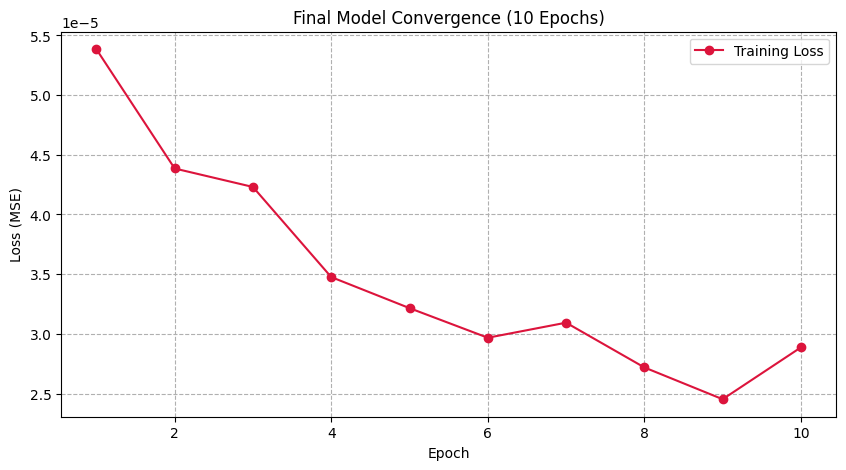

In [19]:
import time
import numpy as np
import matplotlib.pyplot as plt

# 1. Set Device
device = torch.device("cpu")
model.to(device)

# 2. Training Parameters
epochs = 10
train_losses = []

print(f"Starting Full Training on {device} (10 Epochs)...")
total_start_time = time.time()

for epoch in range(epochs):
    model.train()
    batch_losses = []
    epoch_start_time = time.time()

    for batch_idx, (batch_X, batch_y) in enumerate(train_loader):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

        # Progress update every 150 batches for better readability on long runs
        if batch_idx % 150 == 0:
            elapsed = time.time() - epoch_start_time
            print(f"Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.6f} | Elapsed: {elapsed:.1f}s")

    # Calculate Epoch Metrics
    avg_loss = np.mean(batch_losses)
    train_losses.append(avg_loss)
    epoch_duration = time.time() - epoch_start_time

    # Estimate remaining time
    remaining_epochs = epochs - (epoch + 1)
    est_remaining_time = remaining_epochs * epoch_duration

    print(f"\n>>> EPOCH {epoch+1} COMPLETE <<<")
    print(f"Avg Loss: {avg_loss:.6f} | Time: {epoch_duration/60:.2f} min")
    print(f"Est. Remaining Time: {est_remaining_time/60:.2f} min")
    print("-" * 40)

total_duration = time.time() - total_start_time
print(f"--- TRAINING FINISHED ---")
print(f"Total Time: {total_duration/60:.2f} minutes")

# 3. Final Convergence Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o', color='crimson', label='Training Loss')
plt.title('Final Model Convergence (10 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()